Y-Achse reicht von -10.00 bis 15.00 °C


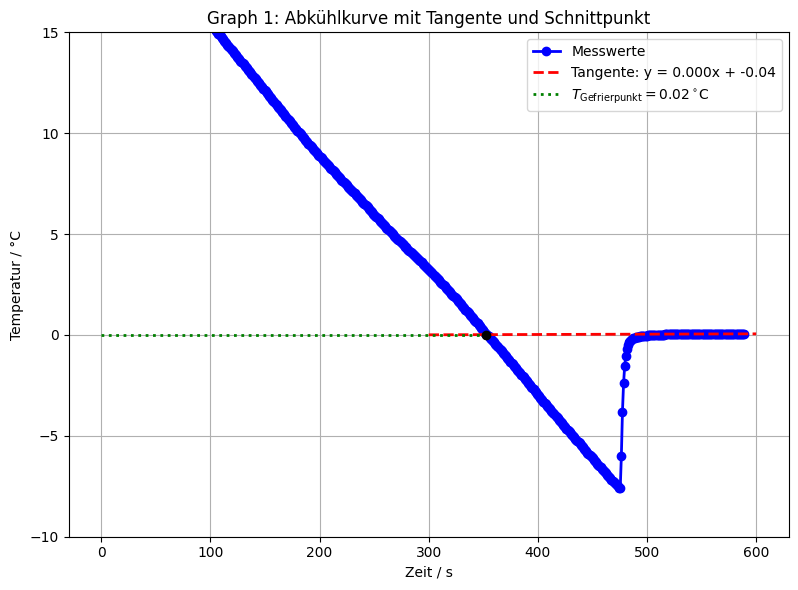

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Reines Wasser.xlsx", engine="openpyxl",
                   usecols="A,B", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ===============================
# Tangente bei ~500 s berechnen
# ===============================
tangente_df = df[(df["Zeit"] >= 520) & (df["Zeit"] <= 590)]
x_tan = tangente_df["Zeit"].values
y_tan = tangente_df["Temperatur"].values
coeffs = np.polyfit(x_tan, y_tan, deg=1)
m, b = coeffs

# Tangentenlinie berechnen
x_line = np.linspace(300, 600, 200)
y_line = m * x_line + b

# ===============================
# Tatsächlichen Schnittpunkt finden
# ===============================
df["Tangente"] = m * df["Zeit"] + b
df["Delta"] = df["Temperatur"] - df["Tangente"]

# Stelle, wo Delta das Vorzeichen wechselt → Schnittpunkt
wechsel_index = np.where(np.diff(np.sign(df["Delta"])))[0][0]
x_schnitt = df["Zeit"].iloc[wechsel_index]
y_schnitt = df["Tangente"].iloc[wechsel_index]

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(8, 6))

# Originalkurve
plt.plot(df["Zeit"], df["Temperatur"], marker='o', linestyle='-', color='blue', label='Messwerte', linewidth=2)

# Tangente
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2,
         label=f"Tangente: y = {m:.3f}x + {b:.2f}")

# Horizontale Linie vom Schnittpunkt zur y-Achse
plt.hlines(y_schnitt, xmin=0, xmax=x_schnitt, color='green', linestyle=':', linewidth=2,
           label = fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f}\,^{{\circ}}\mathrm{{C}}$")

# Schnittpunkt markieren
plt.plot(x_schnitt, y_schnitt, 'ko')  # schwarzer Punkt

# Layout
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Graph 1: Abkühlkurve mit Tangente und Schnittpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Y-Achsenbereich ausgeben
y_limits = plt.ylim(-10, 15)
print(f"Y-Achse reicht von {y_limits[0]:.2f} bis {y_limits[1]:.2f} °C")

plt.show()

Y-Achse reicht von -10.00 bis 5.00 °C
X-Achse reicht von 200.00 bis 600.00 °C


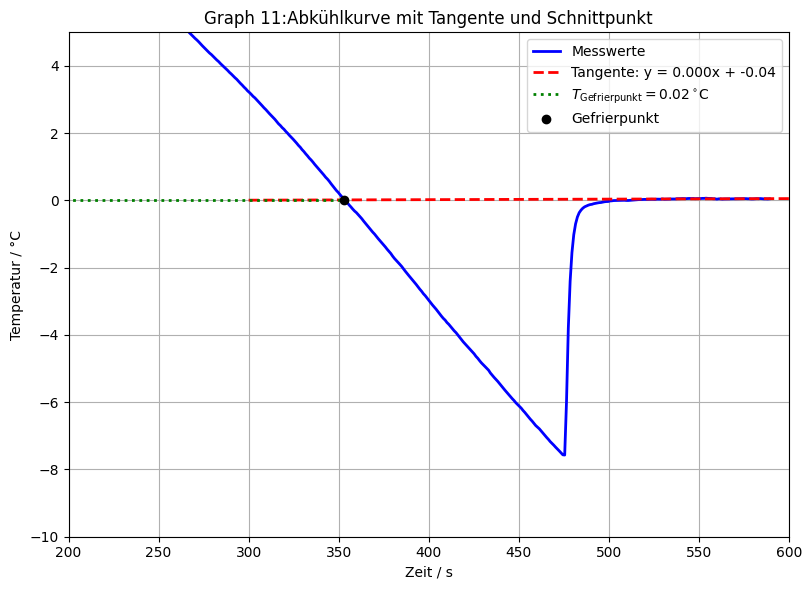

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Reines Wasser.xlsx", engine="openpyxl",
                   usecols="A,B", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ===============================
# Tangente bei ~500 s berechnen
# ===============================
tangente_df = df[(df["Zeit"] >= 520) & (df["Zeit"] <= 590)]
x_tan = tangente_df["Zeit"].values
y_tan = tangente_df["Temperatur"].values
coeffs = np.polyfit(x_tan, y_tan, deg=1)
m, b = coeffs

# Tangentenlinie berechnen
x_line = np.linspace(300, 600, 200)
y_line = m * x_line + b

# ===============================
# Tatsächlichen Schnittpunkt finden
# ===============================
df["Tangente"] = m * df["Zeit"] + b
df["Delta"] = df["Temperatur"] - df["Tangente"]

# Stelle, wo Delta das Vorzeichen wechselt → Schnittpunkt
wechsel_index = np.where(np.diff(np.sign(df["Delta"])))[0][0]
x_schnitt = df["Zeit"].iloc[wechsel_index]
y_schnitt = df["Tangente"].iloc[wechsel_index]

# ===============================
# Plot
# ===============================
plt.figure(figsize=(8, 6))

# Originalkurve
plt.plot(df["Zeit"], df["Temperatur"], color='blue', linewidth=2, label='Messwerte')

# Tangente
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2,
         label=f"Tangente: y = {m:.3f}x + {b:.2f}")

# Horizontale ab Schnittpunkt
if not np.isnan(x_schnitt):
    plt.hlines(y_schnitt, xmin=0, xmax=x_schnitt, color='green', linestyle=':', linewidth=2,
           label = fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f}\,^{{\circ}}\mathrm{{C}}$")
    plt.plot(x_schnitt, y_schnitt, 'ko', label="Gefrierpunkt")  # Punkt markieren

# Layout
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Graph 11:Abkühlkurve mit Tangente und Schnittpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Y-Achsenbereich ausgeben
y_limits = plt.ylim(-10, 5)
print(f"Y-Achse reicht von {y_limits[0]:.2f} bis {y_limits[1]:.2f} °C")

x_limits = plt.xlim(200, 600)
print(f"X-Achse reicht von {x_limits[0]:.2f} bis {x_limits[1]:.2f} °C")

plt.show()

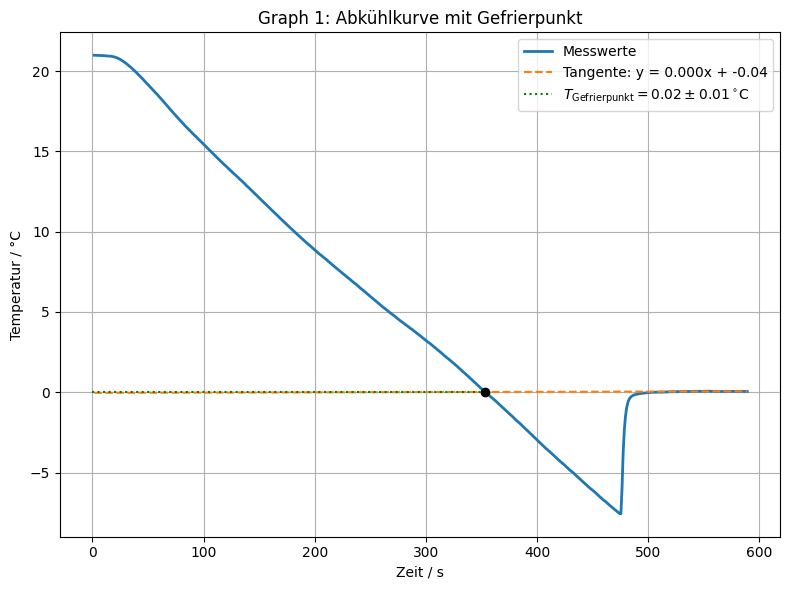

R² der Tangente           : 0.1449
Gefrierpunkt              : 0.02 °C
Standardfehler (1 σ)      : ±0.01 °C
Fit-Parameter m, b        : 0.00016 ± 0.00005,  -0.04 ± 0.03


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit     # <- brauchen wir jetzt wirklich
# ======================================
# Excel laden
# ======================================
df = pd.read_excel("Reines Wasser.xlsx", engine="openpyxl",
                   usecols="A,B", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ======================================
# Lineare Regression im Bereich 520–590 s
# ======================================
fit_mask = (df["Zeit"] >= 520) & (df["Zeit"] <= 590)
x_tan = df.loc[fit_mask, "Zeit"].values
y_tan = df.loc[fit_mask, "Temperatur"].values

def lin(x, m, b):
    return m * x + b

# curve_fit liefert gleich die Kovarianzmatrix
popt, pcov = curve_fit(lin, x_tan, y_tan)
m, b = popt
σ_m, σ_b = np.sqrt(np.diag(pcov))        # Standardfehler von m und b
cov_mb   = pcov[0, 1]                    # Kovarianz m-b

# ======================================
# R² der Regression
# ======================================
y_pred = lin(x_tan, *popt)
ss_res = np.sum((y_tan - y_pred) ** 2)
ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
r2     = 1 - ss_res / ss_tot             # Bestimmtheitsmaß

# ======================================
# Gefrierpunkt bestimmen (Schnittpunkt)
# ======================================
df["Tangente"] = lin(df["Zeit"], *popt)
df["Delta"]    = df["Temperatur"] - df["Tangente"]
wechsel_idx    = np.where(np.diff(np.sign(df["Delta"])))[0][0]

x_schnitt = df["Zeit"].iloc[wechsel_idx]
y_schnitt = df["Tangente"].iloc[wechsel_idx]

# ======================================
# Standardfehler des Gefrierpunkts (ΔT)
#   σ_T² = x²·σ_m² + σ_b² + 2·x·cov(m,b)
# ======================================
σ_T = np.sqrt(x_schnitt**2 * σ_m**2 + σ_b**2 + 2 * x_schnitt * cov_mb)

# ======================================
# Plot
# ======================================
plt.figure(figsize=(8, 6))
plt.plot(df["Zeit"], df["Temperatur"], label="Messwerte", lw=2)
plt.plot(df["Zeit"], df["Tangente"], "--", label=f"Tangente: y = {m:.3f}x + {b:.2f}")
plt.hlines(y_schnitt, 0, x_schnitt, linestyles=":", colors="green",
           label=fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f} \pm {σ_T:.2f}\,^{{\circ}}\mathrm{{C}}$")
plt.plot(x_schnitt, y_schnitt, "ko")

plt.xlabel("Zeit / s"); plt.ylabel("Temperatur / °C")
plt.title("Graph 1: Abkühlkurve mit Gefrierpunkt")
plt.grid(True); plt.legend(); plt.tight_layout()

plt.show()

# ======================================
# Ausgaben
# ======================================
print(f"R² der Tangente           : {r2:.4f}")
print(f"Gefrierpunkt              : {y_schnitt:.2f} °C")
print(f"Standardfehler (1 σ)      : ±{σ_T:.2f} °C")
print(f"Fit-Parameter m, b        : {m:.5f} ± {σ_m:.5f},  {b:.2f} ± {σ_b:.2f}")

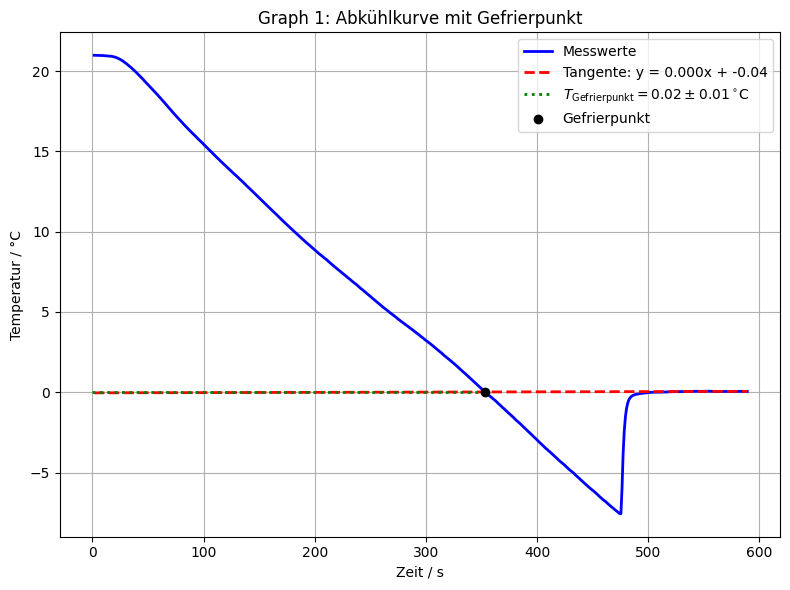

R² der Tangente           : 0.1449
Gefrierpunkt              : 0.02 °C
Standardfehler (1 σ)      : ±0.01 °C
Fit-Parameter m, b        : 0.00016 ± 0.00005,  -0.04 ± 0.03


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ======================================
# Excel-Datei laden
# ======================================
df = pd.read_excel("Reines Wasser.xlsx", engine="openpyxl",
                   usecols="A,B", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ======================================
# Lineare Regression im Bereich 520–590 s
# ======================================
fit_mask = (df["Zeit"] >= 520) & (df["Zeit"] <= 590)
x_tan = df.loc[fit_mask, "Zeit"].values
y_tan = df.loc[fit_mask, "Temperatur"].values

def lin(x, m, b):
    return m * x + b

# Curve Fit mit Kovarianzmatrix
popt, pcov = curve_fit(lin, x_tan, y_tan)
m, b = popt
σ_m, σ_b = np.sqrt(np.diag(pcov))
cov_mb = pcov[0, 1]

# ======================================
# Bestimmtheitsmaß R²
# ======================================
y_pred = lin(x_tan, *popt)
ss_res = np.sum((y_tan - y_pred) ** 2)
ss_tot = np.sum((y_tan - np.mean(y_tan)) ** 2)
r2 = 1 - ss_res / ss_tot

# ======================================
# Schnittpunkt mit Abkühlkurve finden
# ======================================
df["Tangente"] = lin(df["Zeit"], *popt)
df["Delta"] = df["Temperatur"] - df["Tangente"]
wechsel_idx = np.where(np.diff(np.sign(df["Delta"])))[0][0]
x_schnitt = df["Zeit"].iloc[wechsel_idx]
y_schnitt = df["Tangente"].iloc[wechsel_idx]

# ======================================
# Standardfehler des Gefrierpunkts
# ======================================
σ_T = np.sqrt(x_schnitt**2 * σ_m**2 + σ_b**2 + 2 * x_schnitt * cov_mb)

# ======================================
# Plot
# ======================================
plt.figure(figsize=(8, 6))

# Messwerte (blau)
plt.plot(df["Zeit"], df["Temperatur"], color="blue", lw=2, label="Messwerte")

# Tangente (rot, gestrichelt)
plt.plot(df["Zeit"], df["Tangente"], color="red", linestyle="--", lw=2,
         label=f"Tangente: y = {m:.3f}x + {b:.2f}")

# Horizontale Linie am Schnittpunkt (grün, gepunktet)
plt.hlines(y_schnitt, 0, x_schnitt, color="green", linestyle=":", lw=2,
           label=fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f} \pm {σ_T:.2f}\,^{{\circ}}\mathrm{{C}}$")

# Gefrierpunkt markieren
plt.plot(x_schnitt, y_schnitt, "ko", label="Gefrierpunkt")

# Achsenbeschriftung, Titel, Legende
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Graph 1: Abkühlkurve mit Gefrierpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# ======================================
# Ausgaben
# ======================================
print(f"R² der Tangente           : {r2:.4f}")
print(f"Gefrierpunkt              : {y_schnitt:.2f} °C")
print(f"Standardfehler (1 σ)      : ±{σ_T:.2f} °C")
print(f"Fit-Parameter m, b        : {m:.5f} ± {σ_m:.5f},  {b:.2f} ± {σ_b:.2f}")